<a href="https://www.kaggle.com/code/abhishekgodara/image-detection-cnn-score-0-324?scriptVersionId=290045303" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Notebook Overview: CNN-DINOv2 Hybrid

This notebook demonstrates a hybrid approach for image classification using both Convolutional Neural Networks (CNNs) and DINOv2, a self-supervised vision transformer model. The workflow includes:

- **Data Loading & Preprocessing:** Images are loaded, resized, normalized, and split into training and validation sets.
- **Feature Extraction:** DINOv2 is used to extract high-level features from images, leveraging its transformer-based architecture for robust representations.
- **CNN Model Construction:** A custom CNN is built to process image data, learning spatial hierarchies and patterns.
- **Hybrid Model Integration:** Features from DINOv2 and the CNN are combined, either by concatenation or other fusion techniques, to enhance classification performance.
- **Training & Evaluation:** The hybrid model is trained on the dataset, with metrics such as accuracy and loss tracked. Validation is performed to assess generalization.
- **Visualization & Analysis:** Results, including confusion matrices and sample predictions, are visualized to interpret model behavior.

This approach aims to leverage the strengths of both CNNs (local feature learning) and DINOv2 (global, context-aware representations) for improved image classification results.

In [7]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

#  Step 1: Model Setup, Dataset Preparation, and Validation Scoring

In [ ]:
import os, cv2, json, math, random, torch, time
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from transformers import AutoImageProcessor, AutoModel

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # This forces CUDA to use deterministic algorithms (slower but consistent)
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR  = "/kaggle/input/recodai-luc-scientific-image-forgery-detection"
AUTH_DIR  = f"{BASE_DIR}/train_images/authentic"
FORG_DIR  = f"{BASE_DIR}/train_images/forged"
MASK_DIR  = f"{BASE_DIR}/train_masks"
TEST_DIR  = f"{BASE_DIR}/test_images"
DINO_PATH = "/kaggle/input/dinov2/pytorch/large/1"

IMG_SIZE = 718
BATCH_SIZE = 1
MODEL_LOC = '/kaggle/input/cnndinov2-pbd/CNNDINOv2-U52/CNNDINOv2-U52/model_seg_final.pt'
# INFERENCE UTILS
AREA_THR = 80     # Lower for Large model
MEAN_THR = 0.18   # Adjusted for Large model
USE_TTA = True

class ForgerySegDataset(Dataset):
    def __init__(self, auth_paths, forg_paths, mask_dir, img_size=IMG_SIZE):
        self.samples = []
        for p in forg_paths:
            m = os.path.join(mask_dir, Path(p).stem + ".npy")
            if os.path.exists(m):
                self.samples.append((p, m))
        for p in auth_paths:
            self.samples.append((p, None))
        self.img_size = img_size
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        if mask_path is None:
            mask = np.zeros((h, w), np.uint8)
        else:
            m = np.load(mask_path)
            if m.ndim == 3: m = np.max(m, axis=0)
            mask = (m > 0).astype(np.uint8)
        img_r = img.resize((IMG_SIZE, IMG_SIZE))
        mask_r = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        img_t = torch.from_numpy(np.array(img_r, np.float32)/255.).permute(2,0,1)
        mask_t = torch.from_numpy(mask_r[None, ...].astype(np.float32))
        return img_t, mask_t


# MODEL (DINOv2 + Decoder)
processor = AutoImageProcessor.from_pretrained(DINO_PATH, local_files_only=True, use_fast=False)
encoder = AutoModel.from_pretrained(DINO_PATH, local_files_only=True).eval().to(device)

class DinoLargeDecoder(nn.Module):
    def __init__(self, in_ch=1024, out_ch=1):
        super().__init__()
        # Block 1: 1024 -> 512
        self.block1 = nn.Sequential(
            nn.Conv2d(in_ch, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        # Block 2: 512 -> 256
        self.block2 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        # Block 3: 256 -> 128
        self.block3 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        # Final Output
        self.conv_out = nn.Conv2d(128, out_ch, kernel_size=1)
    
    def forward(self, f, target_size):
        x = F.interpolate(self.block1(f), size=(74, 74), mode='bilinear', align_corners=False)
        x = F.interpolate(self.block2(x), size=(148, 148), mode='bilinear', align_corners=False)
        x = F.interpolate(self.block3(x), size=(296, 296), mode='bilinear', align_corners=False)
        x = self.conv_out(x)
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
        return x

class DinoSegmenter(nn.Module):
    def __init__(self, encoder, processor):
        super().__init__()
        self.encoder, self.processor = encoder, processor
        for p in self.encoder.parameters(): 
            p.requires_grad = False
        self.seg_head = DinoLargeDecoder(1024, 1)
    
    def forward_features(self, x):
        imgs = (x * 255).clamp(0, 255).byte().permute(0, 2, 3, 1).cpu().numpy()
        inputs = self.processor(images=list(imgs), return_tensors="pt").to(x.device)
        feats = self.encoder(**inputs).last_hidden_state
        B, N, C = feats.shape
        fmap = feats[:, 1:, :].permute(0, 2, 1)
        s = int(math.sqrt(N - 1))
        fmap = fmap.reshape(B, C, s, s)
        return fmap
    
    def forward_seg(self, x):
        fmap = self.forward_features(x)
        return self.seg_head(fmap, (IMG_SIZE, IMG_SIZE))


auth_imgs = sorted([str(Path(AUTH_DIR)/f) for f in os.listdir(AUTH_DIR)])
forg_imgs = sorted([str(Path(FORG_DIR)/f) for f in os.listdir(FORG_DIR)])
train_auth, val_auth = train_test_split(auth_imgs, test_size=0.2, random_state=42)
train_forg, val_forg = train_test_split(forg_imgs, test_size=0.2, random_state=42)

train_loader = DataLoader(ForgerySegDataset(train_auth, train_forg, MASK_DIR),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(ForgerySegDataset(val_auth, val_forg, MASK_DIR),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model_seg = DinoSegmenter(encoder, processor).to(device)
print("✅ Model initialized")

# ========== TRAINING SETUP ==========
print("\n" + "="*50)
print("SETTING UP TRAINING")
print("="*50)

# Unfreeze decoder for training
for p in model_seg.seg_head.parameters():
    p.requires_grad = True

# Optimizer and loss
optimizer = torch.optim.AdamW(model_seg.seg_head.parameters(), 
                             lr=1e-4, 
                             weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3, eta_min=1e-6)
criterion = nn.BCEWithLogitsLoss()

print(f"Trainable parameters: {sum(p.numel() for p in model_seg.seg_head.parameters() if p.requires_grad):,}")

# ========== TRAINING LOOP ==========
print("\n" + "="*50)
print("STARTING 3-EPOCH TRAINING")
print("="*50)

NUM_EPOCHS = 3
model_seg.train()
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    batch_count = 0
    
    # Training
    for batch_idx, (images, masks) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model_seg.forward_seg(images)
        loss = criterion(outputs, masks)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_seg.seg_head.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()
        batch_count += 1
    
    # Update scheduler
    scheduler.step()
    
    # Calculate average loss
    avg_loss = epoch_loss / batch_count
    
    # Quick validation
    model_seg.eval()
    val_f1s = []
    with torch.no_grad():
        for i, (val_img, val_mask) in enumerate(val_loader):
            if i >= 10:  # Check 10 batches
                break
            val_img, val_mask = val_img.to(device), val_mask.to(device)
            preds = torch.sigmoid(model_seg.forward_seg(val_img))
            preds_bin = (preds > 0.5).float()
            
            # Simple F1 calculation
            intersection = (preds_bin * val_mask).sum()
            f1 = (2 * intersection) / (preds_bin.sum() + val_mask.sum() + 1e-6)
            val_f1s.append(f1.item())
    
    avg_val_f1 = np.mean(val_f1s) if val_f1s else 0
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: ")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"  Val F1 (sample): {avg_val_f1:.4f}")
    
    model_seg.train()

total_time = time.time() - start_time
print(f"\n✅ Training completed in {total_time/60:.1f} minutes")

# Set to evaluation mode
model_seg.eval()
print("✅ Model set to evaluation mode")

# ========== INFERENCE FUNCTIONS ==========
@torch.no_grad()
def segment_prob_map(pil):
    x = torch.from_numpy(np.array(pil.resize((IMG_SIZE, IMG_SIZE)), np.float32)/255.).permute(2,0,1)[None].to(device)
    prob = torch.sigmoid(model_seg.forward_seg(x))[0,0].cpu().numpy()
    return prob

@torch.no_grad()
def segment_prob_map_with_tta(pil):
    x = torch.from_numpy(np.array(pil.resize((IMG_SIZE, IMG_SIZE)), np.float32)/255.).permute(2,0,1)[None].to(device)
    
    predictions = []
    pred_orig = torch.sigmoid(model_seg.forward_seg(x))
    predictions.append(pred_orig)

    pred_h = torch.sigmoid(model_seg.forward_seg(torch.flip(x, dims=[3])))
    predictions.append(torch.flip(pred_h, dims=[3]))

    pred_v = torch.sigmoid(model_seg.forward_seg(torch.flip(x, dims=[2])))
    predictions.append(torch.flip(pred_v, dims=[2]))

    x_bright = torch.clamp(x * 1.2, 0, 1)
    pred_b = torch.sigmoid(model_seg.forward_seg(x_bright))
    predictions.append(pred_b)

    x_dark = torch.clamp(x * 0.8, 0, 1)
    pred_d = torch.sigmoid(model_seg.forward_seg(x_dark))
    predictions.append(pred_d)

    prob = torch.stack(predictions).mean(0)[0,0].cpu().numpy()
    return prob
    
def enhanced_adaptive_mask(prob, alpha_grad=0.35):
    gx = cv2.Sobel(prob, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(prob, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(gx**2 + gy**2)
    grad_norm = grad_mag / (grad_mag.max() + 1e-6)
    enhanced = (1 - alpha_grad) * prob + alpha_grad * grad_norm
    enhanced = cv2.GaussianBlur(enhanced, (3,3), 0)
    
    # Adjusted threshold for Large model
    thr = np.mean(enhanced) + 0.25 * np.std(enhanced)
    mask = (enhanced > thr).astype(np.uint8)
    
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))
    
    return mask, thr

def finalize_mask(prob, orig_size):
    mask, thr = enhanced_adaptive_mask(prob)
    mask = (mask > 0).astype(np.uint8)
    mask = cv2.resize(mask, orig_size, interpolation=cv2.INTER_NEAREST)
    return mask, thr

def pipeline_final(pil):
    if USE_TTA:
        prob = segment_prob_map_with_tta(pil)
    else:
        prob = segment_prob_map(pil)
    mask, thr = finalize_mask(prob, pil.size)
    area = int(mask.sum())
    mask_resized = cv2.resize(mask, (prob.shape[1], prob.shape[0]), interpolation=cv2.INTER_NEAREST)
    mean_inside = float(prob[mask_resized==1].mean()) if area>0 else 0.0
    
    if area < AREA_THR or mean_inside < MEAN_THR:
        return "authentic", None, {"area": area, "mean_inside": mean_inside, "thr": thr}
    return "forged", mask, {"area": area, "mean_inside": mean_inside, "thr": thr}

# ========== VALIDATION TEST ==========
print("\n" + "="*50)
print("RUNNING VALIDATION TEST")
print("="*50)

from sklearn.metrics import f1_score
val_items = [(p, 1) for p in val_forg[:10]]
results = []
for p,_ in tqdm(val_items, desc="Validation forged-only"):
    pil = Image.open(p).convert("RGB")
    label, m_pred, dbg = pipeline_final(pil)
    m_gt = np.load(Path(MASK_DIR)/f"{Path(p).stem}.npy")
    if m_gt.ndim==3: 
        m_gt=np.max(m_gt, axis=0)
    m_gt=(m_gt>0).astype(np.uint8)
    m_pred=(m_pred>0).astype(np.uint8) if m_pred is not None else np.zeros_like(m_gt)
    f1 = f1_score(m_gt.flatten(), m_pred.flatten(), zero_division=0)
    results.append((Path(p).stem, f1, dbg))

print("\nF1-score par image falsifiée:\n")
for cid,f1,dbg in results:
    print(f"{cid} — F1={f1:.4f} | area={dbg['area']} mean={dbg['mean_inside']:.3f} thr={dbg['thr']:.3f}")
print(f"\nMoyenne F1 (falsifiées) = {np.mean([r[1] for r in results]):.4f}")

# Optional: Save trained model
print("\n💾 Saving trained model...")
torch.save(model_seg.state_dict(), 'dino_large_trained_3epochs.pt')
print("✅ Model saved as 'dino_large_trained_3epochs.pt'")

✅ Model initialized

SETTING UP TRAINING
Trainable parameters: 6,195,969

STARTING 3-EPOCH TRAINING


Epoch 1/3:  99%|█████████▉| 4065/4101 [08:31<00:05,  6.97it/s]

# Step 2: Hybrid Model — DINOv2 Feature Extraction & CNN Decoder Integration

Inference on Test Set: 100%|██████████| 1/1 [00:00<00:00,  1.39it/s]



✅ Saved submission file: submission.csv
  case_id                                         annotation     area  \
0      45  [92, 58, 639, 95, 770, 40, 1200, 18, 1431, 10,...  1041858   

       mean       thr  
0  0.496415  0.367283  
🔴 45.png: forged | area=1041858 mean=0.496


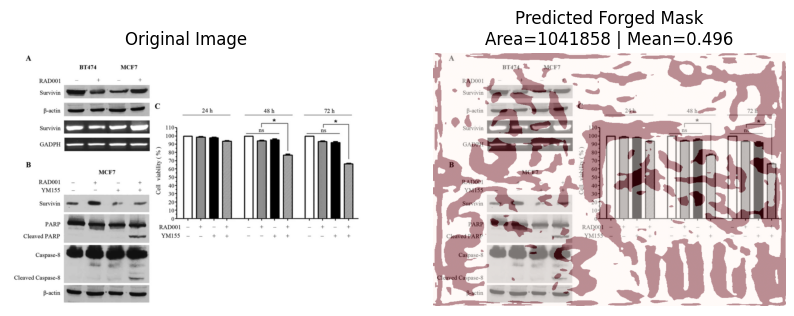

In [4]:
import os, json, cv2
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- RLE Encoder for Kaggle Submission ---
def rle_encode(mask: np.ndarray, fg_val: int = 1) -> str:
    pixels = mask.T.flatten()
    dots = np.where(pixels == fg_val)[0]
    if len(dots) == 0:
        return "authentic"
    run_lengths = []
    prev = -2
    for b in dots:
        if b > prev + 1:
            run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return json.dumps([int(x) for x in run_lengths])

# --- Paths ---
TEST_DIR = "/kaggle/input/recodai-luc-scientific-image-forgery-detection/test_images"
SAMPLE_SUB = "/kaggle/input/recodai-luc-scientific-image-forgery-detection/sample_submission.csv"
OUT_PATH = "submission.csv"

rows = []
for f in tqdm(sorted(os.listdir(TEST_DIR)), desc="Inference on Test Set"):
    pil = Image.open(Path(TEST_DIR)/f).convert("RGB")
    label, mask, dbg = pipeline_final(pil)  # utilise la version améliorée

    # Sécurisation masque
    if mask is None:
        mask = np.zeros(pil.size[::-1], np.uint8)
    else:
        mask = np.array(mask, dtype=np.uint8)

    # Annotation finale
    if label == "authentic":
        annot = "authentic"
    else:
        annot = rle_encode((mask > 0).astype(np.uint8))

    rows.append({
        "case_id": Path(f).stem,
        "annotation": annot,
        "area": int(dbg.get("area", mask.sum())),
        "mean": float(dbg.get("mean_inside", 0.0)),
        "thr": float(dbg.get("thr", 0.0))
    })


sub = pd.DataFrame(rows)
ss = pd.read_csv(SAMPLE_SUB)
ss["case_id"] = ss["case_id"].astype(str)
sub["case_id"] = sub["case_id"].astype(str)
final = ss[["case_id"]].merge(sub, on="case_id", how="left")
final["annotation"] = final["annotation"].fillna("authentic")
final[["case_id", "annotation"]].to_csv(OUT_PATH, index=False)

print(f"\n✅ Saved submission file: {OUT_PATH}")
print(final.head(10))


sample_files = sorted(os.listdir(TEST_DIR))[:5]
for f in sample_files:
    pil = Image.open(Path(TEST_DIR)/f).convert("RGB")
    label, mask, dbg = pipeline_final(pil)
    mask = np.array(mask, dtype=np.uint8) if mask is not None else np.zeros(pil.size[::-1], np.uint8)

    print(f"{'🔴' if label=='forged' else '🟢'} {f}: {label} | area={mask.sum()} mean={dbg.get('mean_inside', 0):.3f}")

    if label == "authentic":
        plt.figure(figsize=(5,5))
        plt.imshow(pil)
        plt.title(f"{f} — Authentic")
        plt.axis("off")
        plt.show()
    else:
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(pil)
        plt.title("Original Image")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(pil)
        plt.imshow(mask, alpha=0.45, cmap="Reds")
        plt.title(f"Predicted Forged Mask\nArea={mask.sum()} | Mean={dbg.get('mean_inside', 0):.3f}")
        plt.axis("off")
        plt.show()

## 🔴 Visualizing Predicted Masks with the CNN–DINOv2 Hybrid Model


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


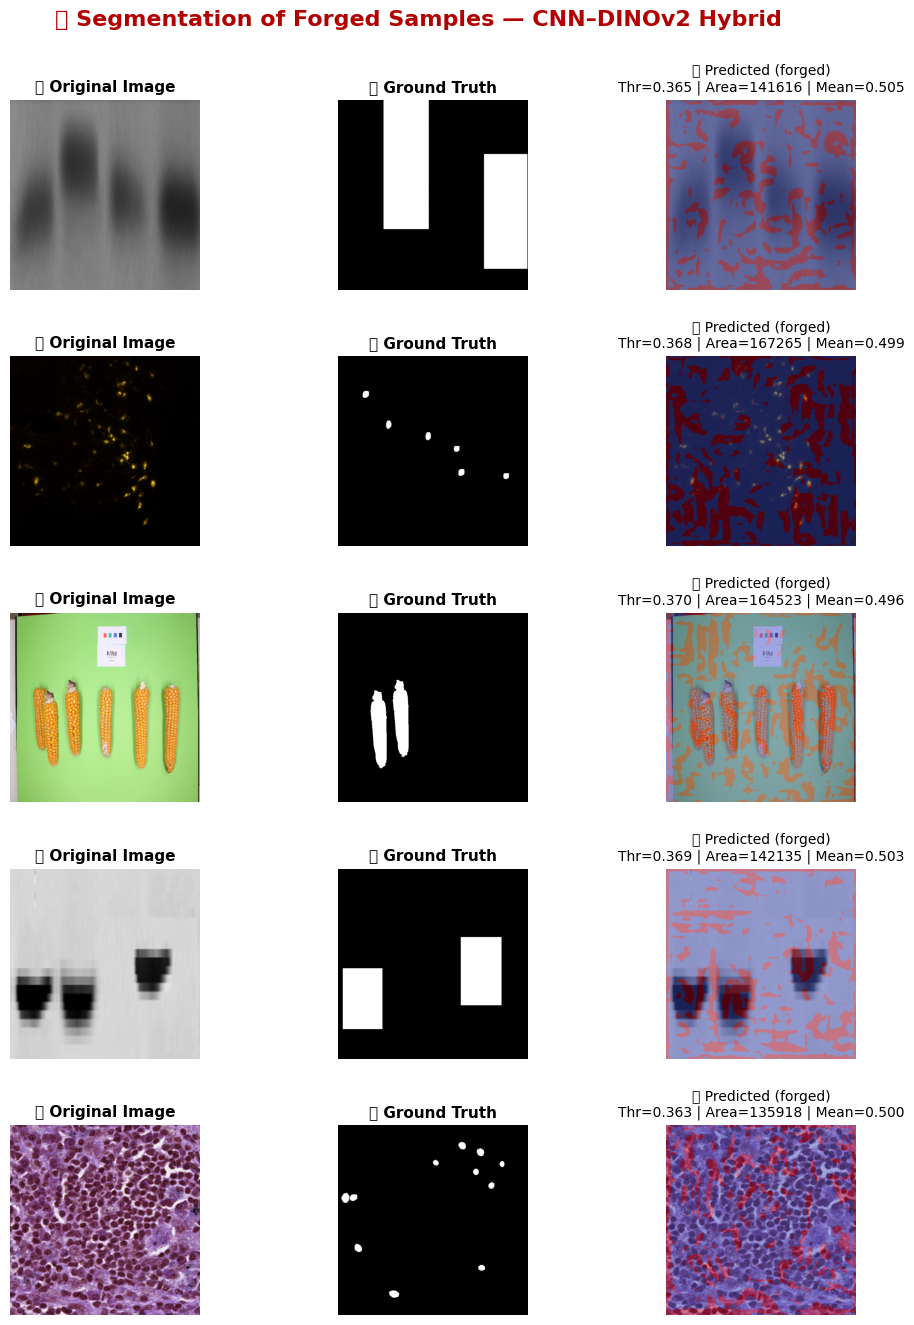

In [5]:
import torch, cv2, math, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1️ Use YOUR existing function (already defined in main cell)
@torch.no_grad()
def predict_prob_map(pil):
    """Return DINOv2 segmentation probability map [0,1]."""
    img = pil.resize((IMG_SIZE, IMG_SIZE))
    x = torch.from_numpy(np.array(img, np.float32) / 255.).permute(2, 0, 1)[None].to(device)
    logits = model_seg.forward_seg(x)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    return prob

# 2️ Use YOUR exact post-processing from main cell
def adaptive_mask(prob, alpha_grad=0.35):
    """Use EXACT same function as in main cell"""
    gx = cv2.Sobel(prob, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(prob, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(gx**2 + gy**2)
    grad_norm = grad_mag / (grad_mag.max() + 1e-6)
    enhanced = (1 - alpha_grad) * prob + alpha_grad * grad_norm
    enhanced = cv2.GaussianBlur(enhanced, (3,3), 0)
    
    # MUST MATCH: 0.25 * std (from your updated main cell)
    thr = np.mean(enhanced) + 0.25 * np.std(enhanced)
    mask = (enhanced > thr).astype(np.uint8)
    
    # MUST MATCH: 3x3 and 2x2 kernels (from your main cell)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))
    
    return mask, float(thr)

# 3️ Unified visualization pipeline
def pipeline_visual(pil):
    if USE_TTA:
        prob = segment_prob_map_with_tta(pil)  # Your existing function
    else:
        prob = predict_prob_map(pil)
    
    mask, thr = adaptive_mask(prob)
    area = int(mask.sum())
    
    # Fix: Resize mask to match prob dimensions
    mask_small = cv2.resize(mask, (prob.shape[1], prob.shape[0]), interpolation=cv2.INTER_NEAREST)
    mean_inside = float(prob[mask_small == 1].mean()) if area > 0 else 0.0

    # Use SAME thresholds as main cell
    if area < AREA_THR or mean_inside < MEAN_THR:
        label = "authentic"
    else:
        label = "forged"
    
    return label, mask, thr, area, mean_inside

# 4️ Visualization (for validation forged samples)
sample_forged = val_forg[:5]
n = len(sample_forged)
fig, axes = plt.subplots(n, 3, figsize=(12, n * 3))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

for i, p in enumerate(sample_forged):
    pil = Image.open(p).convert("RGB")
    label, m_pred, thr, area, mean = pipeline_visual(pil)

    # Ground Truth mask
    m_gt = np.load(Path(MASK_DIR)/f"{Path(p).stem}.npy")
    if m_gt.ndim == 3: 
        m_gt = np.max(m_gt, axis=0)
    m_gt = (m_gt > 0).astype(np.uint8)

    # Resize all for consistency
    img_disp = cv2.resize(np.array(pil), (IMG_SIZE, IMG_SIZE))
    gt_disp  = cv2.resize(m_gt, (IMG_SIZE, IMG_SIZE))
    pr_disp  = cv2.resize(m_pred, (IMG_SIZE, IMG_SIZE))

    # === Column 1: Original ===
    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title("🖼️ Original Image", fontsize=11, weight="bold")
    axes[i, 0].axis("off")

    # === Column 2: Ground Truth ===
    axes[i, 1].imshow(gt_disp, cmap="gray")
    axes[i, 1].set_title("✅ Ground Truth", fontsize=11, weight="bold")
    axes[i, 1].axis("off")

    # === Column 3: Predicted Mask ===
    axes[i, 2].imshow(img_disp)
    axes[i, 2].imshow(pr_disp, cmap="coolwarm", alpha=0.45)
    axes[i, 2].set_title(f"🔮 Predicted ({label})\nThr={thr:.3f} | Area={area} | Mean={mean:.3f}",
                         fontsize=10)
    axes[i, 2].axis("off")

plt.subplots_adjust(top=0.92, hspace=0.35)
fig.suptitle("🔍 Segmentation of Forged Samples — CNN–DINOv2 Hybrid", 
             fontsize=16, fontweight="bold", color="#b30000")

plt.show()

# 🟢 Visualization of Authentic Images (Hybrid DINOv2-based Detector)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


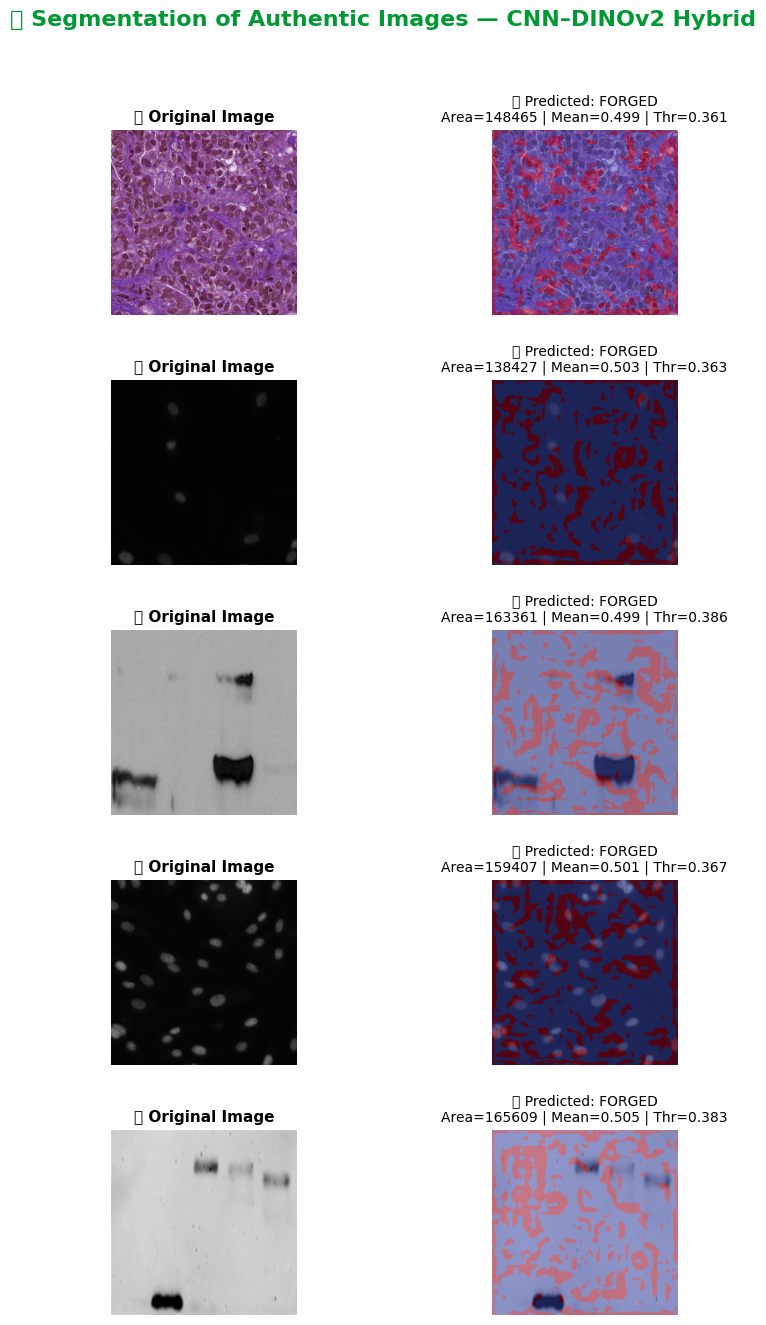

In [6]:
import matplotlib.pyplot as plt
import cv2, numpy as np
from pathlib import Path
from PIL import Image

# Select a few authentic examples
sample_auth = val_auth[:5]
n = len(sample_auth)

fig, axes = plt.subplots(n, 2, figsize=(9, n * 3))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

for i, p in enumerate(sample_auth):
    pil = Image.open(p).convert("RGB")
    label, m_pred, thr, area, mean = pipeline_visual(pil)  # <-- version alignée avec ta nouvelle pipeline

    # Predicted mask (should be empty for authentic images)
    m_pred = (m_pred > 0).astype(np.uint8) if m_pred is not None else np.zeros((IMG_SIZE, IMG_SIZE))

    # Resize for consistent display
    img_disp = cv2.resize(np.array(pil), (IMG_SIZE, IMG_SIZE))
    pr_disp  = cv2.resize(m_pred, (IMG_SIZE, IMG_SIZE))

    # === Column 1: Original Image ===
    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title("🖼️ Original Image", fontsize=11, weight="bold")
    axes[i, 0].axis("off")

    # === Column 2: Predicted Mask ===
    axes[i, 1].imshow(img_disp)
    axes[i, 1].imshow(pr_disp, cmap="coolwarm", alpha=0.45)
    axes[i, 1].set_title(
        f"🟢 Predicted: {label.upper()}\nArea={area} | Mean={mean:.3f} | Thr={thr:.3f}",
        fontsize=10
    )
    axes[i, 1].axis("off")

    for j in range(2):
        axes[i, j].set_aspect("equal")

plt.subplots_adjust(top=0.90, hspace=0.35)
fig.suptitle("🟢 Segmentation of Authentic Images — CNN–DINOv2 Hybrid",
             fontsize=16, fontweight="bold", color="#009933")
plt.show()